# 03b — Pre-Event State Conditioning — YM

## Research question

Notebook 02 estimated the **unconditional** response of ES futures to macroeconomic surprises.
CPI is the only strong signal: a 1-SD hotter headline print lowers ES by roughly 18–24 bps.

This notebook asks:

> **Does the market's state *before* the release change how ES responds to the *same* surprise?**

If it does, a strategy can scale or filter trades by state (Notebook 04). If it does not, that is also a result: the surprise-only model is the right benchmark.

> **03b — E-mini Dow (YM).** This notebook is Notebook 03 (ES) run on **YM**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_YM.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **NQ** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the YM contract (tick 1 index point, $5 per point).
> - Outputs are saved as `nb03b_YM_*` (results, figures) and `event_state_features_2016_2026_YM.parquet`, so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the YM results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens | Output |
|---|---|---|
| 1 | Setup, paths, pre-registered parameters | — |
| 2 | Load NB02 event data, build the signed surprise `x` | event table |
| 3 | Load ES 1-minute data, roll-adjust the continuous contract | adjusted log price |
| 4 | Daily close and daily state features | `rv_20d`, `mom_20d`, `dd_60d`, … |
| 5 | Event-level state features and no-look-ahead checks | state table |
| 6 | Post-release drift returns (the tradeable part) | `drift_{h}m_bps` |
| 7 | State descriptives | correlations, bucket balance |
| 8 | Bucket analysis: surprise beta in Low / Mid / High states | `nb03_bucket_betas.csv` |
| 9 | Interaction regressions | `nb03_interaction_results.csv` |
| 10 | Permutation tests and multiple-testing (BH-FDR) correction | q-values |
| 11 | Subperiod stability (2016–2020 vs 2021–2026) | sign agreement |
| 12 | Does the state predict the **size** of the move? | `nb03_magnitude_results.csv` |
| 13 | Pre-registered selection rule, then hand-off to Notebook 04 | `nb03_state_selection.csv`, `event_state_features_2016_2026.parquet` |

## Methodology: design rules fixed *before* looking at results

1. **No look-ahead.** Every state variable for an event at time $T$ uses ES bars strictly before $T$. The last bar used is the $T-1$ bar, the same `pre_close` as in NB02. Daily features come from the 16:00 ET close of the previous trading day.
2. **Causal normalisation.** Each state is converted to a percentile against a **trailing 1-year** distribution ending before the event date. For intraday states the reference is measured at the **same clock time** (08:30 or 10:00 ET) every day. No full-sample z-scores or quantiles are used.
3. **Roll adjustment.** `ES.c.0` is an unadjusted continuous front-month series. Multi-day features use a roll-adjusted log price (1-minute returns across an `instrument_id` change are set to 0).
4. **Signed surprise.** One headline signal per family, signed by economic theory and NB02 so that $x>0$ means *good news for equities*:
   $x_{CPI} = -z_{headline\,CPI}$, $x_{PCE} = -z_{headline\,PCE}$, $x_{NFP} = +z_{payrolls}$. The sign is fixed, not re-estimated.
5. **Pre-registered states.** Six primary states, each with an economic hypothesis (table below). Everything else is labelled *exploratory*.
6. **Pre-registered targets.** `ret_5m_bps` (response including the instant jump) and `drift_30m_bps` (the post-release drift, which a strategy can actually trade).
7. **Multiple testing.** Benjamini–Hochberg FDR is applied across all interaction tests, together with a permutation test.

### Pre-registered state variables and hypotheses

| State | Definition (known before $T$) | Hypothesis |
|---|---|---|
| `rv_20d` | 20-day realised vol of daily closes (annualised %) | High-vol regimes → larger surprise beta (uncertainty, thinner liquidity) |
| `rv_pre_1d` | Realised vol of 5-min returns over the last ~23 trading hours (bps) | Short-term stress amplifies the reaction |
| `mom_20d` | 20-day log return (%) | After strong rallies, bad news hits harder (stretched positioning) |
| `dd_60d` | Distance from the 60-day high (%) | In drawdowns, the market is more sensitive to inflation news |
| `overnight_ret` | Prior 16:00 ET close → $T-1$ (bps) | A large pre-release move signals partial pre-positioning, so less left to react |
| `prev_x` | Previous signed surprise of the same family | Surprise streaks: a second hot print confirms the trend, so a larger response |

**Exploratory (reported, not used for selection):** `mom_5d`, `ma50_gap`, `rv_pre_60m`, `ret_pre_60m`.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ------------------------------------------------------------
# Project paths (same convention as NB01/NB02)
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "YM"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0), "YM": (1.0, 5.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EVENT_MODEL_FILE = PROCESSED_DIR / "macro_event_model_data_2016_2026.parquet"

# Helper module
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
importlib.reload(sc)

print("Project root:", PROJECT_ROOT)
print("Event file exists:", EVENT_MODEL_FILE.exists())
print(f"{MARKET} raw file exists:", MARKET_FILE.exists())

Project root: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises
Event file exists: True
YM raw file exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = YM | file: futures_1min_clean_v3_YM.parquet (exists: True) | tick 1, $5 per point | cost 2 ticks + $4.50 = 2.9000 points per round trip


### 1.1 Pre-registered parameters
These are fixed **before** any result is examined. Changing them after seeing results would invalidate the multiple-testing correction.

In [3]:
FAMILIES = ["CPI", "NFP", "PCE", "ALL"]          # ALL = pooled, family-specific slopes

PRIMARY_STATES = ["rv_20d", "rv_pre_1d", "mom_20d", "dd_60d", "overnight_ret", "prev_x"]
EXPLORATORY_STATES = ["mom_5d", "ma50_gap", "rv_pre_60m", "ret_pre_60m"]

RET_TARGETS = [f"ret_{h}m_bps" for h in sc.HORIZONS]            # from T-1 (NB02 definition)
DRIFT_TARGETS = [f"drift_{h}m_bps" for h in sc.DRIFT_HORIZONS]  # from T (tradeable)
ALL_TARGETS = RET_TARGETS + DRIFT_TARGETS

PRIMARY_TARGETS = ["ret_5m_bps", "drift_30m_bps"]

TRAILING_WINDOW_DAYS = 365   # percentile reference window
SPLIT_DATE = "2021-01-01"    # subperiod split: 2016-2020 vs 2021-2026
N_PERM = 2000                # permutations per primary test
FDR_Q = 0.10

print("Primary states:", PRIMARY_STATES)
print("Primary targets:", PRIMARY_TARGETS)

Primary states: ['rv_20d', 'rv_pre_1d', 'mom_20d', 'dd_60d', 'overnight_ret', 'prev_x']
Primary targets: ['ret_5m_bps', 'drift_30m_bps']


## 2. Load NB02 Event Data and Build the Signed Surprise

In [4]:
events = pd.read_parquet(EVENT_MODEL_FILE)
events["timestamp_utc"] = pd.to_datetime(events["timestamp_utc"], utc=True)
events = events.sort_values("timestamp_utc").reset_index(drop=True)

print("Event rows:", len(events))
print("Unique timestamps:", events["timestamp_utc"].nunique())
print("Range:", events["timestamp_utc"].min(), "to", events["timestamp_utc"].max())
display(events["event_type"].value_counts().rename("n_events").to_frame())
display(events.head())

assert events["timestamp_utc"].is_unique
assert set(RET_TARGETS).issubset(events.columns)

Event rows: 363
Unique timestamps: 363
Range: 2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00


,n_events
event_type,
NFP,122
CPI,122
PCE,119


,timestamp_utc,event_type,avg_hourly_earnings,core_cpi,core_pce,headline_cpi,headline_pce,nonfarm_payrolls,unemployment_rate,pre_close,ret_1m_bps,ret_5m_bps,ret_15m_bps,ret_30m_bps,ret_60m_bps
0,2016-01-08 13:30:00+00:00,NFP,-0.9769,NaN,NaN,NaN,NaN,1.6143,0.4340,"1,950.5000",34.5468,65.1551,26.8800,17.9280,-19.2443
1,2016-01-20 13:30:00+00:00,CPI,NaN,-1.0924,NaN,-0.8034,NaN,NaN,NaN,"1,843.0000",-2.7133,6.7801,-1.3566,9.4909,9.4909
2,2016-02-01 13:30:00+00:00,PCE,NaN,NaN,-1.3234,NaN,-1.3212,NaN,NaN,"1,915.5000",1.3051,-2.6106,14.3463,11.7394,19.5580
3,2016-02-05 13:30:00+00:00,NFP,1.6753,NaN,NaN,NaN,NaN,-0.5663,-0.2453,"1,909.0000",-32.7934,-59.1057,-39.3650,-52.5211,-23.6004
4,2016-02-19 13:30:00+00:00,CPI,NaN,1.4020,NaN,1.1648,NaN,NaN,NaN,"1,910.5000",-14.4045,-3.9264,-7.8544,-27.5175,-23.5818


In [5]:
# ---- replace the ES prices of the NB02 event file with MARKET prices -------------
# Same releases and surprises as NB02; only the prices change.
_bars = load_market_minute()
_adj, _ = sc.build_adjusted_log_price(_bars)
_idx = _adj.index.as_unit("ns") if hasattr(_adj.index, "as_unit") else _adj.index
_tns, _lp, _cl = _idx.asi8, _adj["logp_adj"].to_numpy(), _adj["close"].to_numpy()
_T = pd.DatetimeIndex(events["timestamp_utc"]); _T = _T.as_unit("ns") if hasattr(_T, "as_unit") else _T
def _at(label, arr):
    x = _T.asi8 + label * 60 * 10**9
    pos = np.searchsorted(_tns, x, side="right") - 1
    ok = (pos >= 0) & ((x - _tns[np.clip(pos, 0, None)]) <= 5 * 60 * 10**9)
    return np.where(ok, arr[np.clip(pos, 0, None)], np.nan)
events["pre_close"] = _at(-1, _cl)
_pre = _at(-1, _lp)
for h in sc.HORIZONS:
    events[f"ret_{h}m_bps"] = (_at(h - 1, _lp) - _pre) * 1e4
events = events[events["pre_close"].notna()].reset_index(drop=True)
print(f"{MARKET}: event returns rebuilt for {len(events)} releases")

# x > 0 must mean good news for THIS market. A hot CPI/PCE print is bad for ES, NQ and ZN alike,
# but a strong payrolls print is good for equities and BAD for bond prices (ZN).
if MARKET == "ZN":
    sc.FAMILY_SIGNAL = {**sc.FAMILY_SIGNAL, "NFP": ("nonfarm_payrolls", -1.0)}
print("Signal signs used:", sc.FAMILY_SIGNAL)

YM: event returns rebuilt for 348 releases
Signal signs used: {'CPI': ('headline_cpi', -1.0), 'PCE': ('headline_pce', -1.0), 'NFP': ('nonfarm_payrolls', 1.0)}


In [6]:
events = sc.add_signed_surprise(events)

print("Signed-surprise definition:")
for fam, (col, sign) in sc.FAMILY_SIGNAL.items():
    print(f"  {fam}: x = {sign:+.0f} * {col}")

print("\nMissing x by family:")
display(events.groupby("event_type")["x"].apply(lambda v: v.isna().sum()).rename("missing_x").to_frame())

# Sanity check: x should be POSITIVELY related to returns (by construction of the sign)
sanity = (
    events.groupby("event_type")
    .apply(lambda g: pd.Series({f"corr(x, {c})": g["x"].corr(g[c]) for c in ["ret_1m_bps", "ret_5m_bps", "ret_30m_bps"]}))
)
display(sanity)

Signed-surprise definition:
  CPI: x = -1 * headline_cpi
  PCE: x = -1 * headline_pce
  NFP: x = +1 * nonfarm_payrolls

Missing x by family:


,missing_x
event_type,
CPI,0
NFP,0
PCE,0


,"corr(x, ret_1m_bps)","corr(x, ret_5m_bps)","corr(x, ret_30m_bps)"
event_type,,,
CPI,0.5278,0.5133,0.4742
NFP,0.1897,0.2161,0.2982
PCE,0.2960,0.3003,0.2084


**Checkpoint.** For CPI (and PCE) the correlation between `x` and returns should be clearly **positive**, consistent with the negative headline coefficients in NB02. NFP will be weak, as in NB02.

## 3. Load ES 1-Minute Data and Roll-Adjust the Continuous Contract

In [7]:
es = load_market_minute()
print(f"{MARKET} bars:", len(es))
print("Range:", es.index.min(), "to", es.index.max())
print("Distinct instrument_ids:", es["instrument_id"].nunique())

es_adj, rolls = sc.build_adjusted_log_price(es)
print("\nNumber of contract rolls detected:", len(rolls))
display(rolls.tail(10))

YM bars: 5195343
Range: 2010-07-01 00:00:00+00:00 to 2026-06-30 20:59:00+00:00
Distinct instrument_ids: 65

Number of contract rolls detected: 64


,timestamp_utc,from_instrument,to_instrument,raw_jump_bps
54,2024-03-17 22:00:00+00:00,204839,80420,28.6687
55,2024-06-23 22:00:00+00:00,80420,42012334,191.7595
56,2024-09-22 22:00:00+00:00,42012334,42006053,192.6704
57,2024-12-22 23:00:00+00:00,42006053,42002868,-11.0482
58,2025-03-23 22:00:00+00:00,42002868,42003068,143.4201
59,2025-06-22 22:00:00+00:00,42003068,42003287,-75.9599
60,2025-09-21 22:00:00+00:00,42003287,42004629,166.9661
61,2025-12-21 23:00:00+00:00,42004629,42005850,20.4029
62,2026-03-22 22:00:00+00:00,42005850,42004838,-287.6715
63,2026-06-21 22:00:00+00:00,42004838,42003638,13.5187


In [8]:
# Validation: the roll adjustment only removes jumps at instrument changes.
# Within a contract, adjusted log returns must equal raw log returns.
raw_r = np.log(es["close"]).diff().to_numpy()
same_contract = np.r_[False, es["instrument_id"].to_numpy()[1:] == es["instrument_id"].to_numpy()[:-1]]
max_diff = np.nanmax(np.abs(raw_r[same_contract] - es_adj["r1"].to_numpy()[same_contract]))
print("Max |raw - adjusted| 1-min return within contracts:", max_diff)
assert max_diff < 1e-12

print("\nRaw price jump at rolls (bps), which is removed from multi-day features:")
display(rolls["raw_jump_bps"].describe().to_frame())

Max |raw - adjusted| 1-min return within contracts: 0.0

Raw price jump at rolls (bps), which is removed from multi-day features:


,raw_jump_bps
count,64.0000
mean,-8.5338
std,186.1573
min,-793.0742
25%,-45.9109
50%,10.9004
75%,80.8364
max,393.6703


**Why this matters.** The continuous series `ES.c.0` jumps at each quarterly roll by the calendar spread. Without adjustment, a 20-day momentum or drawdown measure spanning a roll would partly measure the spread, not the market move.

## 4. Daily Close and Daily State Features

In [9]:
daily = sc.build_daily_close(es_adj)
daily_feats = sc.compute_daily_features(daily)

print("Trading days:", len(daily))
print("Range:", daily.index.min().date(), "to", daily.index.max().date())
display(daily_feats.dropna().tail())
display(daily_feats[sc.DAILY_STATE].describe().T)

Trading days: 3748
Range: 2010-07-01 to 2026-06-30


,rv_20d,mom_5d,mom_20d,dd_60d,ma50_gap,daily_close_ts_utc
date_et,,,,,,
2026-06-24,14.2395,2.6046,4.1457,0.0000,4.1986,2026-06-24 19:59:00+00:00
2026-06-25,14.1818,2.0659,3.7491,0.0000,4.1991,2026-06-25 19:59:00+00:00
2026-06-26,14.2325,0.6729,2.8387,-0.3501,3.6900,2026-06-26 19:59:00+00:00
2026-06-29,14.3122,0.8370,3.7310,0.0000,4.2355,2026-06-29 19:59:00+00:00
2026-06-30,14.3050,1.1382,3.6319,0.0000,4.2971,2026-06-30 19:59:00+00:00


,count,mean,std,min,25%,50%,75%,max
rv_20d,"3,730.0000",13.8587,8.5402,3.1775,9.0589,11.7792,15.9001,92.6806
mom_5d,"3,743.0000",0.2312,2.2003,-24.7379,-0.7812,0.3677,1.3992,18.3440
mom_20d,"3,728.0000",0.9007,4.1125,-38.6062,-1.1539,1.2852,3.3442,23.8756
dd_60d,"3,699.0000",-2.9327,3.8423,-38.9287,-4.1435,-1.4588,-0.3122,0.0000
ma50_gap,"3,704.0000",1.0962,3.4222,-32.2346,-0.6455,1.6316,3.2116,14.4628


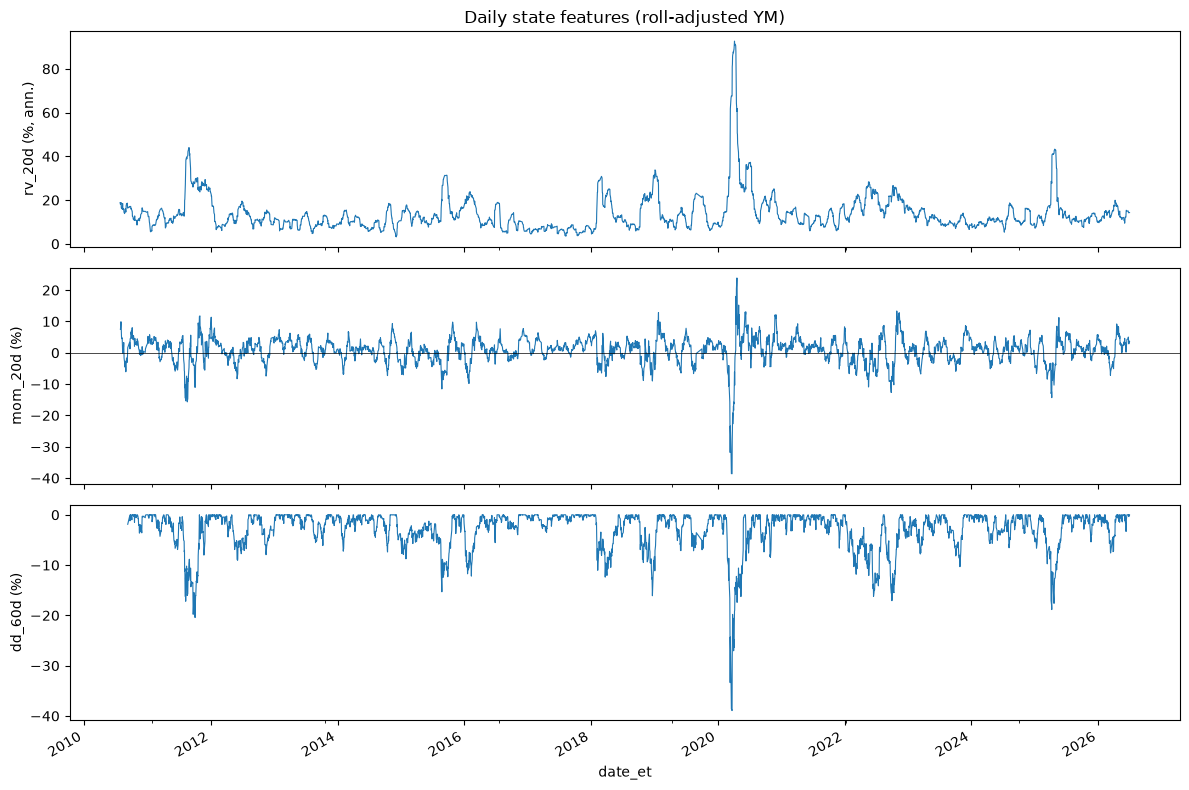

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
daily_feats["rv_20d"].plot(ax=axes[0], lw=0.8); axes[0].set_ylabel("rv_20d (%, ann.)")
daily_feats["mom_20d"].plot(ax=axes[1], lw=0.8); axes[1].axhline(0, c="k", lw=0.5); axes[1].set_ylabel("mom_20d (%)")
daily_feats["dd_60d"].plot(ax=axes[2], lw=0.8); axes[2].set_ylabel("dd_60d (%)")
axes[0].set_title(f"Daily state features (roll-adjusted {MARKET})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"nb03b_{MARKET}_daily_state_features.png", dpi=150)
plt.show()

## 5. Event-Level State Features

For each event: daily features from the previous trading day; intraday features from bars before $T$; causal percentiles (`*_pct`); and the previous same-family surprise.

This step also computes the **same-clock-time reference distribution** for intraday states, which takes a little longer (roughly a minute).

In [11]:
ev = sc.build_event_states(events, es_adj, daily, daily_feats, window_days=TRAILING_WINDOW_DAYS)

ALL_STATES = PRIMARY_STATES + EXPLORATORY_STATES
ev = sc.add_state_buckets(ev, ALL_STATES)

show_cols = ["timestamp_utc", "event_type", "x"] + [c for s in PRIMARY_STATES for c in (s, f"{s}_pct")]
display(ev[show_cols].head(10))

,timestamp_utc,event_type,x,rv_20d,rv_20d_pct,rv_pre_1d,rv_pre_1d_pct,mom_20d,mom_20d_pct,dd_60d,dd_60d_pct,overnight_ret,overnight_ret_pct,prev_x,prev_x_pct
0,2016-01-08 13:30:00+00:00,NFP,1.6143,20.3632,0.8948,170.3081,0.9614,-3.8860,0.1609,-7.1272,0.1567,84.2966,0.9399,NaN,NaN
1,2016-01-20 13:30:00+00:00,CPI,0.8034,21.2883,0.8991,169.8846,0.9528,-4.2973,0.1352,-10.1631,0.0837,-182.4568,0.0129,NaN,NaN
2,2016-02-01 13:30:00+00:00,PCE,1.3212,23.3436,0.9116,100.6677,0.7241,-6.7570,0.0582,-7.4627,0.1875,-72.9818,0.0819,NaN,NaN
3,2016-02-05 13:30:00+00:00,NFP,-0.5663,23.5580,0.9077,160.3820,0.9270,-2.8895,0.2597,-7.6217,0.1824,-3.6729,0.4506,1.6143,0.9468
4,2016-02-19 13:30:00+00:00,CPI,-1.1648,21.0471,0.8176,87.3663,0.6094,4.3428,0.8991,-7.3894,0.2339,-23.2302,0.2833,0.8034,0.7891
5,2016-02-26 15:00:00+00:00,PCE,-2.1147,19.6546,0.7575,90.8032,0.6137,4.9880,0.9292,-5.6281,0.3069,25.7647,0.7082,1.3212,0.9068
6,2016-03-04 13:30:00+00:00,NFP,0.8511,17.8565,0.6974,60.1979,0.2489,4.0517,0.8906,-4.1039,0.4914,14.7610,0.5708,-0.5663,0.2856
7,2016-03-28 12:30:00+00:00,PCE,-0.3590,12.3241,0.3772,48.8859,0.0776,4.7801,0.8815,-2.7193,0.7047,26.9442,0.6552,-2.1147,0.0172
8,2016-04-01 12:30:00+00:00,NFP,0.2326,9.9607,0.1137,61.4502,0.2704,3.8971,0.8305,-1.7311,0.8133,-31.3114,0.2275,0.8511,0.8027
9,2016-04-14 12:30:00+00:00,CPI,0.8159,9.2126,0.0662,54.6824,0.1239,3.2371,0.7756,0.0000,0.9808,6.1720,0.5214,-1.1648,0.1221


### 5.1 No-look-ahead validation

In [12]:
checks = {}

# (a) last intraday bar used is strictly before the release, and equals the NB02 pre-event bar (T-1)
checks["asof < T (all events)"] = bool((ev["asof_utc"] < ev["timestamp_utc"]).all())
checks["asof == T-1min (share)"] = float((ev["asof_utc"] == ev["timestamp_utc"] - pd.Timedelta(minutes=1)).mean())

# (b) raw close at the as-of bar matches NB02 pre_close
raw_pre = es["close"].reindex(ev["asof_utc"]).to_numpy()
checks["close(asof) == NB02 pre_close"] = bool(np.allclose(raw_pre, ev["pre_close"], equal_nan=False))

# (c) daily features come from a date strictly before the event date
checks["feature date < event date"] = bool((pd.to_datetime(ev["feat_date_et"]) < ev["date_et"]).all())

# (d) previous close used for overnight return is before T
checks["prev close ts < T"] = bool((pd.to_datetime(ev["prev_close_ts_utc"], utc=True) < ev["timestamp_utc"]).all())

# (e) prev_x only uses earlier events of the same family
first_idx = ev.groupby("event_type")["timestamp_utc"].idxmin()
checks["first event per family has no prev_x"] = bool(ev.loc[first_idx, "prev_x"].isna().all())

display(pd.Series(checks, name="result").to_frame())
assert checks["asof < T (all events)"]
assert checks["asof == T-1min (share)"] == 1.0
assert checks["close(asof) == NB02 pre_close"]
assert checks["feature date < event date"]
assert checks["prev close ts < T"]
print("ALL NO-LOOK-AHEAD CHECKS PASSED")

,result
asof < T (all events),True
asof == T-1min (share),1.0000
close(asof) == NB02 pre_close,True
feature date < event date,True
prev close ts < T,True
first event per family has no prev_x,True


ALL NO-LOOK-AHEAD CHECKS PASSED


### 5.2 State coverage

In [13]:
coverage = pd.DataFrame({
    "raw_non_missing": [ev[s].notna().sum() for s in ALL_STATES],
    "pct_non_missing": [ev[f"{s}_pct"].notna().sum() for s in ALL_STATES],
}, index=ALL_STATES)
coverage["n_events"] = len(ev)
coverage["primary"] = coverage.index.isin(PRIMARY_STATES)
display(coverage)

,raw_non_missing,pct_non_missing,n_events,primary
rv_20d,348,348,348,True
rv_pre_1d,348,348,348,True
mom_20d,348,348,348,True
dd_60d,348,348,348,True
overnight_ret,348,348,348,True
prev_x,345,345,348,True
mom_5d,348,348,348,False
ma50_gap,348,348,348,False
rv_pre_60m,348,348,348,False
ret_pre_60m,348,348,348,False


A few events may lack a percentile. This happens when the trailing reference window has fewer than 150 observations, or for the first event of each family (`prev_x`). Those events drop out of the tests for that state only.

## 6. Post-Release Drift Returns (the Tradeable Part)

NB02 returns run from the $T-1$ close and therefore include the **instant jump**, which no strategy reacting to the number can capture. The drift return starts at the close of the first post-release bar (label $T$):

$$D_{T,h} = \ln\left(\frac{P_{T+h-1}}{P_{T}}\right)$$

Because log returns add up: $R_{T,h} = R_{T,1} + D_{T,h}$. This identity is checked below.

In [14]:
ev = sc.add_drift_returns(ev, es_adj)

for h in sc.DRIFT_HORIZONS:
    gap = (ev[f"ret_{h}m_bps"] - (ev["ret_1m_bps"] + ev[f"drift_{h}m_bps"])).abs().max()
    print(f"h={h:>2}: max |ret_h - (ret_1 + drift_h)| = {gap:.2e} bps")
    assert gap < 1e-6

display(ev.groupby("event_type")[DRIFT_TARGETS].agg(lambda v: v.abs().mean()).round(2)
        .rename(columns=lambda c: "mean|" + c + "|"))

h= 5: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps
h=15: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps
h=30: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps
h=60: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps


,mean|drift_5m_bps|,mean|drift_15m_bps|,mean|drift_30m_bps|,mean|drift_60m_bps|
event_type,,,,
CPI,11.9200,15.1800,18.2500,18.7500
NFP,9.8600,14.4800,17.4500,21.4500
PCE,4.7900,8.4500,10.1500,13.6800


## 7. State Descriptives

,rv_20d_pct,rv_pre_1d_pct,mom_20d_pct,dd_60d_pct,overnight_ret_pct,prev_x_pct
rv_20d_pct,1.0000,0.6200,-0.2300,-0.5300,-0.0600,-0.1000
rv_pre_1d_pct,0.6200,1.0000,-0.4300,-0.7000,-0.0900,0.0400
mom_20d_pct,-0.2300,-0.4300,1.0000,0.6600,0.0200,-0.0500
dd_60d_pct,-0.5300,-0.7000,0.6600,1.0000,0.0500,0.0200
overnight_ret_pct,-0.0600,-0.0900,0.0200,0.0500,1.0000,-0.1300
prev_x_pct,-0.1000,0.0400,-0.0500,0.0200,-0.1300,1.0000


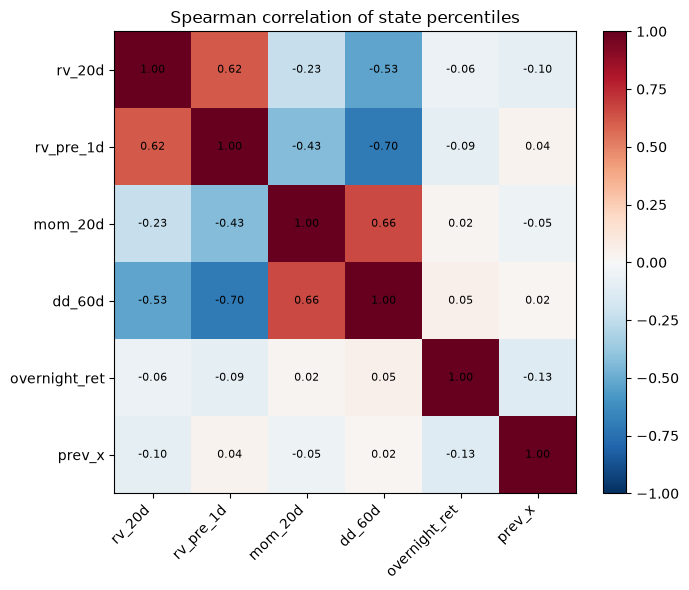

In [15]:
pct_cols = [f"{s}_pct" for s in PRIMARY_STATES]
corr = ev[pct_cols].corr(method="spearman")
display(corr.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(pct_cols))); ax.set_xticklabels(PRIMARY_STATES, rotation=45, ha="right")
ax.set_yticks(range(len(pct_cols))); ax.set_yticklabels(PRIMARY_STATES)
for i in range(len(pct_cols)):
    for j in range(len(pct_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Spearman correlation of state percentiles")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb03b_{MARKET}_state_correlation.png", dpi=150); plt.show()

**How to read it.** Highly correlated states (for example `rv_20d` and `dd_60d`, since drawdowns coincide with high volatility) are **not independent evidence**. If both pass, treat them as one volatility/stress regime.

In [16]:
# Bucket balance: causal terciles need not be exactly 1/3 each, since they are relative to the trailing year
bal = pd.concat({s: ev[f"{s}_bucket"].value_counts(normalize=True) for s in PRIMARY_STATES}, axis=1).T
display(bal.round(2))

# Bucket counts per family, which shows how thin the cells are
display(pd.concat({s: ev.groupby("event_type")[f"{s}_bucket"].value_counts().unstack() for s in PRIMARY_STATES}))

,Low,High,Mid
rv_20d,0.3900,0.3400,0.2800
rv_pre_1d,0.3600,0.3400,0.2900
mom_20d,0.3400,0.3300,0.3200
dd_60d,0.3300,0.3500,0.3200
overnight_ret,0.3300,0.3100,0.3600
prev_x,0.2200,0.2300,0.5500


Low  Mid  High
              event_type                
rv_20d        CPI          45   28    40
              NFP          49   27    43
              PCE          40   42    34
rv_pre_1d     CPI          42   37    34
              NFP          43   30    46
              PCE          42   35    39
mom_20d       CPI          37   38    38
              NFP          46   38    35
              PCE          37   36    43
dd_60d        CPI          39   30    44
              NFP          42   41    36
              PCE          35   39    42
overnight_ret CPI          34   49    30
              NFP          37   45    37
              PCE          44   30    42
prev_x        CPI          35   43    34
              NFP          19   76    23
              PCE          21   71    23

## 8. Bucket Analysis: Surprise Beta by State Tercile

Within each state bucket $k\in\{\text{Low},\text{Mid},\text{High}\}$:

$$r_i = a_k + \beta_k\, x_i + \varepsilon_i$$

If the state matters, $\beta$ should change **monotonically** from Low to High. Standard errors are HC3.

In [17]:
bucket = sc.bucket_betas(ev, ALL_STATES, FAMILIES, ALL_TARGETS)
bucket.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_bucket_betas.csv", index=False)

cpi_view = (
    bucket[(bucket["family"] == "CPI") & bucket["state"].isin(PRIMARY_STATES) & bucket["target"].isin(PRIMARY_TARGETS)]
    .pivot_table(index=["state", "target"], columns="bucket", values="beta")
    [["Low", "Mid", "High"]]
)
cpi_view["High - Low"] = cpi_view["High"] - cpi_view["Low"]
print("CPI: surprise beta (bps per 1-SD good-news surprise) by state bucket")
display(cpi_view.round(2))

CPI: surprise beta (bps per 1-SD good-news surprise) by state bucket


bucket                          Low     Mid    High  High - Low
state         target                                           
dd_60d        drift_30m_bps 15.1100 -0.9700  3.5300    -11.5800
              ret_5m_bps    45.2600 17.6800 12.8600    -32.4000
mom_20d       drift_30m_bps  2.4100  8.5100  3.9200      1.5100
              ret_5m_bps    24.9500 25.1200 16.7800     -8.1700
overnight_ret drift_30m_bps -3.3000 11.6000  8.8100     12.1100
              ret_5m_bps     6.4300 30.6100 40.1600     33.7300
prev_x        drift_30m_bps  3.7400  6.7400  5.7500      2.0100
              ret_5m_bps    21.2200 26.6300 24.6500      3.4300
rv_20d        drift_30m_bps -1.2900  9.7500 17.0100     18.3000
              ret_5m_bps     7.5500 42.7900 51.8000     44.2400
rv_pre_1d     drift_30m_bps  4.4500  7.0700  3.0000     -1.4500
              ret_5m_bps    18.1400 30.3000 21.3500      3.2100

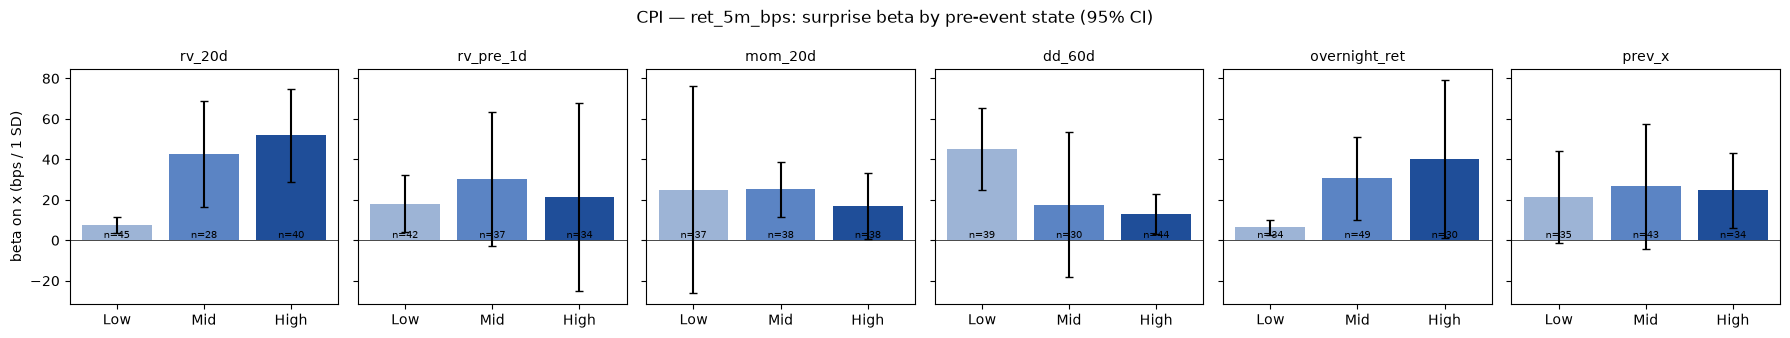

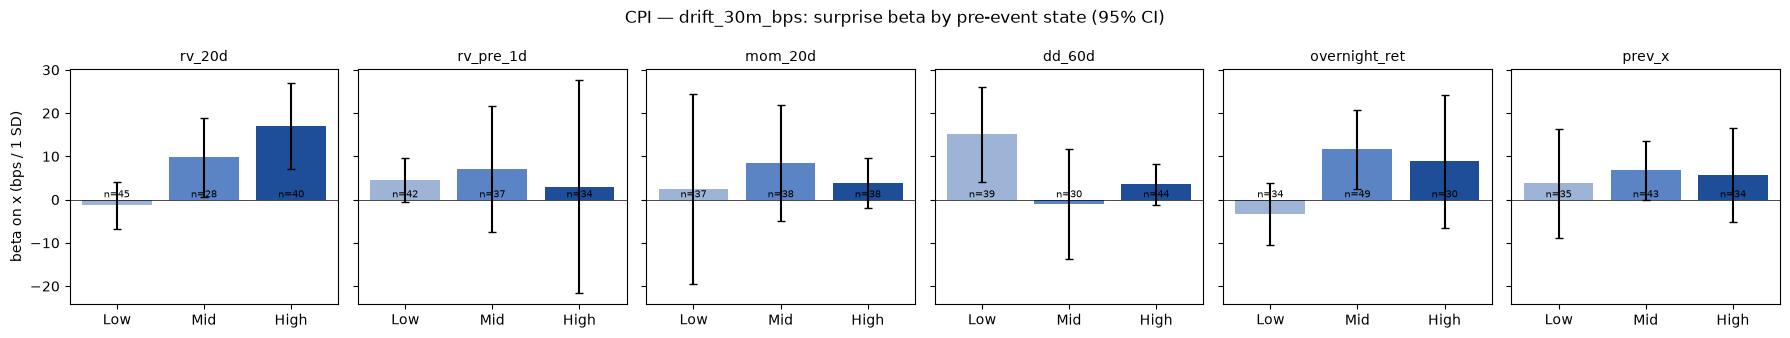

In [18]:
def plot_bucket_betas(bucket, family, target, states, fname):
    sub = bucket[(bucket.family == family) & (bucket.target == target) & bucket.state.isin(states)]
    fig, axes = plt.subplots(1, len(states), figsize=(3.0 * len(states), 3.4), sharey=True)
    for ax, s in zip(np.atleast_1d(axes), states):
        d = sub[sub.state == s].set_index("bucket").reindex(["Low", "Mid", "High"])
        ax.bar(d.index, d["beta"], yerr=1.96 * d["se"], capsize=3, color=["#9db4d6", "#5b84c4", "#1f4e99"])
        ax.axhline(0, c="k", lw=0.5)
        ax.set_title(s, fontsize=10)
        for k, (b, n) in enumerate(zip(d["beta"], d["n"])):
            if np.isfinite(b):
                ax.text(k, 0, f"n={int(n)}", ha="center", va="bottom", fontsize=7)
    np.atleast_1d(axes)[0].set_ylabel("beta on x (bps / 1 SD)")
    fig.suptitle(f"{family} — {target}: surprise beta by pre-event state (95% CI)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for tgt in PRIMARY_TARGETS:
    plot_bucket_betas(bucket, "CPI", tgt, PRIMARY_STATES, f"nb03b_{MARKET}_cpi_bucket_betas_{tgt}.png")

**How to read it.** Wide error bars are expected, since each CPI bucket holds about 40 events. Look for a **monotone** Low → Mid → High pattern that repeats across both targets. A single tall bar is not evidence on its own.

## 9. Interaction Regressions

Using the full sample in one regression is more efficient than splitting it into buckets:

$$r_i = a + b\,x_i + c\,s_i + d\,(x_i \times s_i) + \varepsilon_i, \qquad s_i = \text{pct}_i - 0.5$$

- $b$: surprise beta at the **median** state
- $c$: does the state predict the return on its own (direction)?
- $d$: **the key coefficient**, the change in surprise beta from the lowest to the highest state percentile

Since $x$ is signed so that $b>0$, a **positive $d$** means *a stronger reaction in the high state*.
The pooled (`ALL`) model has family-specific intercepts and slopes and a common $c$ and $d$.

In [19]:
inter = sc.interaction_tests(ev, ALL_STATES, FAMILIES, ALL_TARGETS,
                             n_perm=N_PERM, perm_targets=PRIMARY_TARGETS)
inter["primary_state"] = inter["state"].isin(PRIMARY_STATES)

# FDR is applied to the PRIMARY family of tests only (primary states x families x primary targets)
prim_mask = inter["primary_state"] & inter["target"].isin(PRIMARY_TARGETS)
inter["q_bh_primary"] = np.nan
inter.loc[prim_mask, "q_bh_primary"] = sc.bh_fdr(inter.loc[prim_mask, "p_interact"])
inter.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_interaction_results.csv", index=False)

print("Number of primary tests (FDR family):", prim_mask.sum())
display(
    inter[prim_mask]
    .sort_values("p_interact")
    [["state", "family", "target", "n", "b_x", "d_interact", "t_interact", "p_interact", "p_perm", "q_bh_primary", "r2"]]
    .round(4)
)

Number of primary tests (FDR family): 48


,state,family,target,n,b_x,d_interact,t_interact,p_interact,p_perm,q_bh_primary,r2
1,rv_20d,CPI,ret_5m_bps,113,28.6806,58.6661,3.7352,0.0003,0.0040,0.0144,0.4721
10,rv_20d,NFP,ret_5m_bps,119,5.2016,-17.2947,-3.1140,0.0023,0.0145,0.0422,0.1109
46,rv_pre_1d,NFP,ret_5m_bps,119,5.3904,-21.0185,-3.0745,0.0026,0.0125,0.0422,0.1017
205,prev_x,PCE,drift_30m_bps,115,1.6479,-8.9734,-2.6764,0.0086,0.0145,0.1028,0.0582
145,overnight_ret,CPI,ret_5m_bps,113,24.0438,60.7826,2.5169,0.0133,0.0300,0.1069,0.4316
7,rv_20d,CPI,drift_30m_bps,113,7.2781,24.6027,2.5151,0.0134,0.0320,0.1069,0.2226
178,overnight_ret,ALL,drift_30m_bps,348,NaN,5.9412,2.4119,0.0164,0.0630,0.1124,0.0756
16,rv_20d,NFP,drift_30m_bps,119,4.4796,-14.2051,-2.2751,0.0248,0.0795,0.1485,0.1203
52,rv_pre_1d,NFP,drift_30m_bps,119,3.9183,-14.1518,-2.1065,0.0373,0.0785,0.1991,0.1062
19,rv_20d,PCE,ret_5m_bps,116,4.5589,11.0104,2.0513,0.0426,0.0305,0.2043,0.1673


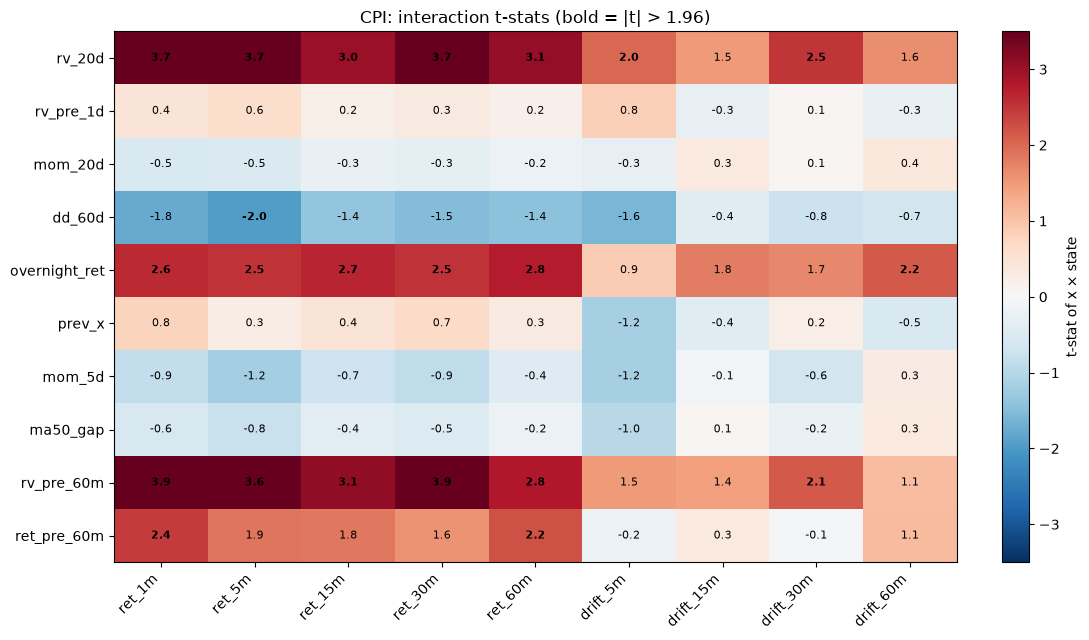

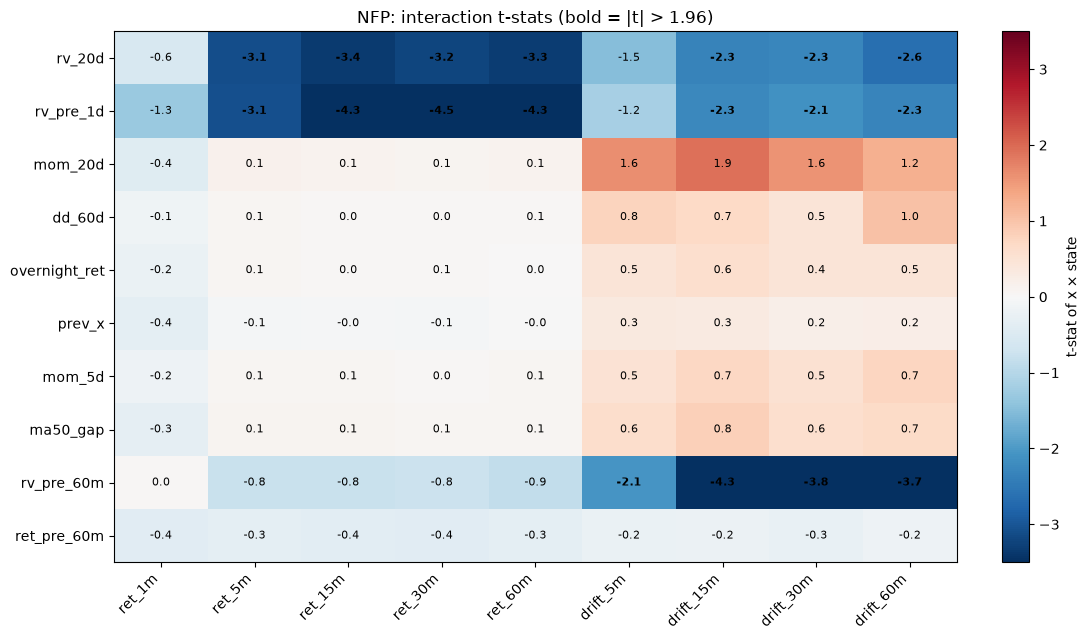

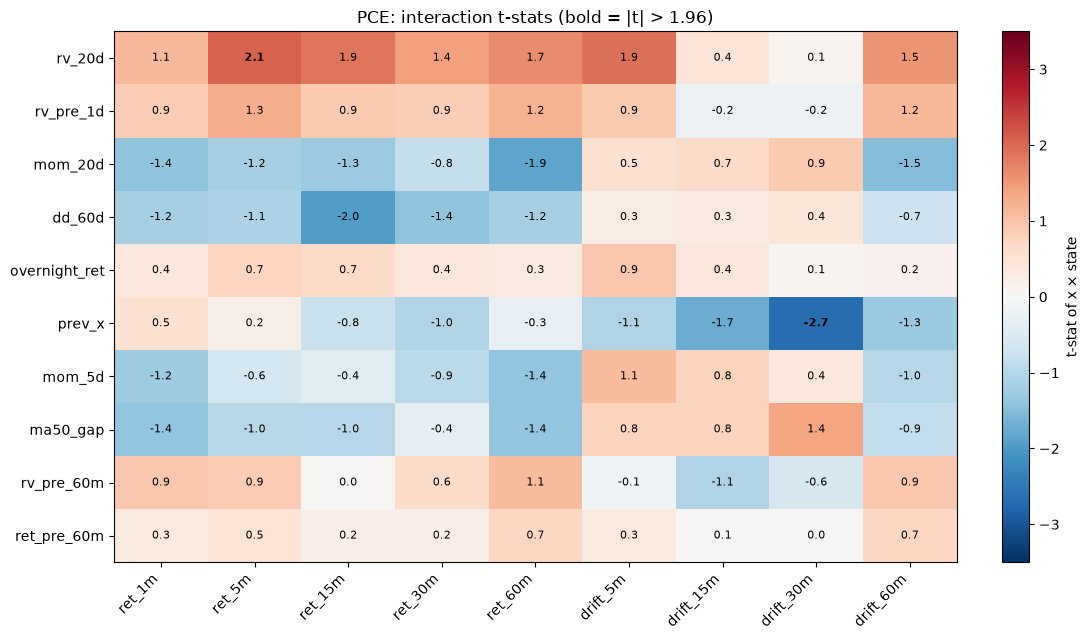

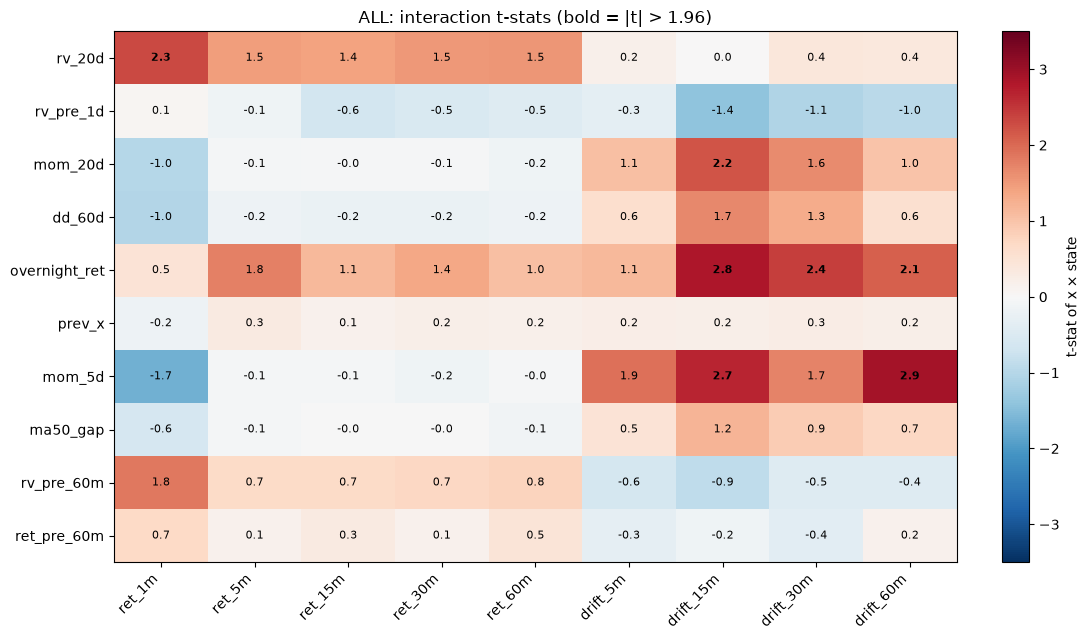

In [20]:
def tstat_heatmap(inter, family, states, targets, fname):
    m = (inter[(inter.family == family) & inter.state.isin(states)]
         .pivot_table(index="state", columns="target", values="t_interact")
         .reindex(index=states, columns=targets))
    fig, ax = plt.subplots(figsize=(1.0 * len(targets) + 2, 0.5 * len(states) + 1.5))
    im = ax.imshow(m.values, cmap="RdBu_r", vmin=-3.5, vmax=3.5, aspect="auto")
    ax.set_xticks(range(len(targets))); ax.set_xticklabels([t.replace("_bps", "") for t in targets], rotation=45, ha="right")
    ax.set_yticks(range(len(states))); ax.set_yticklabels(states)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                        fontweight="bold" if abs(v) > 1.96 else "normal")
    plt.colorbar(im, ax=ax, fraction=0.03, label="t-stat of x × state")
    ax.set_title(f"{family}: interaction t-stats (bold = |t| > 1.96)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for fam in FAMILIES:
    tstat_heatmap(inter, fam, ALL_STATES, ALL_TARGETS, f"nb03b_{MARKET}_interaction_tstats_{fam}.png")

**How to read it.** A credible state effect looks like a **row of same-coloured cells** across horizons. A single bold cell among about 90 is what chance alone produces: at 5% significance, roughly 4–5 false positives are expected.

## 10. Permutation Tests and Multiple-Testing Control

- **Permutation p-value.** The state percentile is shuffled across events *within each family* 2,000 times. This breaks any link between the state and the surprise while keeping each family's returns intact. It makes no normality assumption.
- **BH-FDR q-value.** This controls the expected share of false discoveries across the primary tests.

,count
primary tests,48.0000
expected false positives at 5% (if no true effect),2.4000
naive p < 0.05,10.0000
permutation p < 0.05,8.0000
BH q < 0.1,3.0000


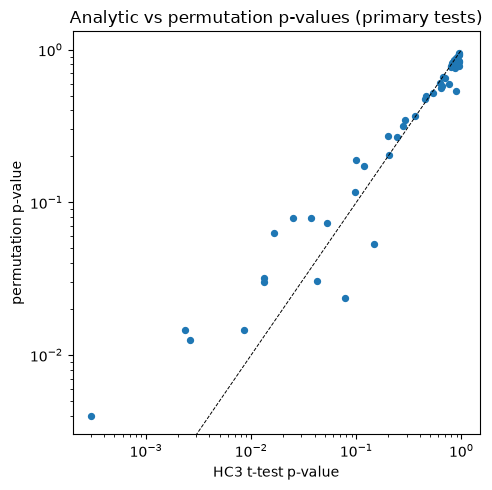

In [21]:
pt = inter[prim_mask].copy()
pt["sig_naive_5pct"] = pt["p_interact"] < 0.05
pt["sig_perm_5pct"] = pt["p_perm"] < 0.05
pt["sig_fdr"] = pt["q_bh_primary"] < FDR_Q

summary_mt = pd.Series({
    "primary tests": len(pt),
    "expected false positives at 5% (if no true effect)": round(0.05 * len(pt), 1),
    "naive p < 0.05": int(pt["sig_naive_5pct"].sum()),
    "permutation p < 0.05": int(pt["sig_perm_5pct"].sum()),
    f"BH q < {FDR_Q}": int(pt["sig_fdr"].sum()),
})
display(summary_mt.to_frame("count"))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pt["p_interact"], pt["p_perm"], s=18)
ax.plot([0, 1], [0, 1], "k--", lw=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("HC3 t-test p-value"); ax.set_ylabel("permutation p-value")
ax.set_title("Analytic vs permutation p-values (primary tests)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb03b_{MARKET}_pvalue_comparison.png", dpi=150); plt.show()

If the number of naive "significant" results is close to the expected false-positive count, the evidence for state dependence is weak **as a whole**, even if individual p-values look good.

## 11. Subperiod Stability

The sample spans two very different inflation regimes: low and stable in 2016–2020, then the 2021+ inflation shock and hiking cycle. A usable state effect should keep its sign in both.

In [22]:
stab = sc.subperiod_stability(ev, ALL_STATES, FAMILIES, ALL_TARGETS, split_date=SPLIT_DATE)
stab.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_subperiod_stability.csv", index=False)

display(
    stab[stab.state.isin(PRIMARY_STATES) & stab.target.isin(PRIMARY_TARGETS)]
    .sort_values(["family", "state", "target"])
    .round(3)
)

share = (stab[stab.state.isin(PRIMARY_STATES)]
         .groupby(["family", "state"])["same_sign"].mean().unstack("family").round(2))
print("Share of horizons with the same interaction sign in both subperiods:")
display(share)

,state,family,target,n_early,d_interact_early,t_interact_early,n_late,d_interact_late,t_interact_late,same_sign
142,dd_60d,ALL,drift_30m_bps,163,2.6590,0.9450,185,1.3160,0.1770,True
136,dd_60d,ALL,ret_5m_bps,163,0.1530,0.0500,185,-15.4500,-1.0130,False
106,mom_20d,ALL,drift_30m_bps,163,3.3260,0.7390,185,9.6500,1.0650,True
100,mom_20d,ALL,ret_5m_bps,163,-0.1140,-0.0150,185,-0.1970,-0.0080,True
178,overnight_ret,ALL,drift_30m_bps,163,3.3260,0.3410,185,28.5000,2.7900,True
172,overnight_ret,ALL,ret_5m_bps,163,1.8660,0.1430,185,63.9510,3.0110,True
214,prev_x,ALL,drift_30m_bps,160,1.9740,0.4580,185,-6.9540,-0.7790,False
208,prev_x,ALL,ret_5m_bps,160,0.2740,0.0850,185,7.9520,0.4310,True
34,rv_20d,ALL,drift_30m_bps,163,-3.9560,-0.5160,185,13.5130,1.2730,False
28,rv_20d,ALL,ret_5m_bps,163,-1.9430,-0.1650,185,49.4320,2.7940,False


Share of horizons with the same interaction sign in both subperiods:


family,ALL,CPI,NFP,PCE
state,,,,
dd_60d,0.5600,0.8900,0.8900,0.5600
mom_20d,0.6700,0.0000,0.4400,0.5600
overnight_ret,0.8900,0.7800,0.7800,0.2200
prev_x,0.4400,0.5600,0.2200,0.6700
rv_20d,0.1100,1.0000,0.8900,0.6700
rv_pre_1d,0.7800,0.4400,1.0000,0.4400


## 12. Does the State Predict the *Size* of the Move?

Even if the state does not change the *direction* coefficient, it may predict **how big** the move is, which matters for position sizing and risk limits in Notebook 04:

$$|r_i| = a + g\,|x_i| + h\,s_i + \varepsilon_i$$

In [23]:
mag = sc.magnitude_tests(ev, ALL_STATES, FAMILIES, ALL_TARGETS)
mag.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_magnitude_results.csv", index=False)

display(
    mag[mag.state.isin(PRIMARY_STATES) & mag.target.isin(["ret_5m_bps", "ret_30m_bps", "drift_30m_bps"])]
    .sort_values("p_state")
    .round(4)
    .head(20)
)

,state,family,target,n,r2,g_abs_x,h_state,t_state,p_state,q_bh
70,rv_pre_1d,ALL,drift_30m_bps,348,0.1313,0.9554,15.1320,5.1723,0.0000,0.0000
34,rv_20d,ALL,drift_30m_bps,348,0.1295,0.9552,14.6253,5.1225,0.0000,0.0000
142,dd_60d,ALL,drift_30m_bps,348,0.1331,1.0848,-15.4917,-4.9825,0.0000,0.0000
61,rv_pre_1d,PCE,drift_30m_bps,116,0.1850,-0.5561,17.5294,3.8997,0.0002,0.0035
106,mom_20d,ALL,drift_30m_bps,348,0.1010,1.1067,-12.2306,-3.6720,0.0003,0.0049
30,rv_20d,ALL,ret_30m_bps,348,0.0630,1.4401,20.1029,3.6476,0.0003,0.0049
147,overnight_ret,CPI,ret_30m_bps,113,0.1944,11.6730,67.8211,3.4855,0.0007,0.0065
136,dd_60d,ALL,ret_5m_bps,348,0.0614,1.0619,-20.0829,-3.4041,0.0007,0.0067
115,dd_60d,CPI,drift_30m_bps,113,0.1637,4.0278,-20.1724,-3.3965,0.0010,0.0079
28,rv_20d,ALL,ret_5m_bps,348,0.0476,0.9083,16.1557,3.3283,0.0010,0.0079


**Expected pattern.** Volatility states (`rv_20d`, `rv_pre_1d`) usually show a strong positive $h$: in high-vol regimes, moves are bigger regardless of the surprise. That is useful for **risk scaling** even if it does not improve the **directional** signal.

## 13. Pre-Registered Selection Rule and Hand-off to Notebook 04

A (state, family) pair is carried into Notebook 04 only if, on a primary target, it passes **all** of these:

1. BH-FDR q < 0.10 (primary test family)
2. permutation p < 0.05
3. the interaction has the same sign in 2016–2020 and in 2021–2026
4. the interaction sign agrees on at least 60% of all nine targets

If nothing passes, Notebook 04 uses the **surprise-only** model as the main strategy, and state is used only for risk scaling (Section 12), if at all.

In [24]:
inter_primary = inter[prim_mask].copy()
inter_primary["q_bh"] = inter_primary["q_bh_primary"]   # use the primary-family FDR
all_for_agreement = inter[inter.state.isin(PRIMARY_STATES)].copy()

# horizon agreement uses ALL targets; significance uses the primary targets only
sel = sc.select_states(
    pd.concat([inter_primary, all_for_agreement[~all_for_agreement.index.isin(inter_primary.index)]]),
    stab, PRIMARY_TARGETS, q_max=FDR_Q,
)
sel.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_state_selection.csv", index=False)

display(sel[["state", "family", "target", "n", "d_interact", "t_interact", "p_perm", "q_bh",
             "same_sign", "horizon_sign_agreement",
             "pass_fdr", "pass_perm", "pass_stability", "pass_horizons", "selected"]].round(3))

selected_pairs = sel.loc[sel["selected"], ["state", "family"]].drop_duplicates()
print("\nSELECTED (state, family) pairs for Notebook 04:")
print(selected_pairs.to_string(index=False) if len(selected_pairs) else "  none. Use surprise-only as the main model.")

,state,family,target,n,d_interact,t_interact,p_perm,q_bh,same_sign,horizon_sign_agreement,pass_fdr,pass_perm,pass_stability,pass_horizons,selected
0,rv_20d,CPI,ret_5m_bps,113,58.6660,3.7350,0.0040,0.0140,True,1.0000,True,True,True,True,True
2,rv_20d,NFP,ret_5m_bps,119,-17.2950,-3.1140,0.0140,0.0420,True,1.0000,True,True,True,True,True
10,rv_pre_1d,NFP,ret_5m_bps,119,-21.0190,-3.0740,0.0120,0.0420,True,1.0000,True,True,True,True,True
45,prev_x,PCE,drift_30m_bps,115,-8.9730,-2.6760,0.0140,0.1030,True,0.7780,False,True,True,True,False
1,rv_20d,CPI,drift_30m_bps,113,24.6030,2.5150,0.0320,0.1070,True,1.0000,False,True,True,True,False
32,overnight_ret,CPI,ret_5m_bps,113,60.7830,2.5170,0.0300,0.1070,True,1.0000,False,True,True,True,False
39,overnight_ret,ALL,drift_30m_bps,348,5.9410,2.4120,0.0630,0.1120,True,1.0000,False,False,True,True,False
3,rv_20d,NFP,drift_30m_bps,119,-14.2050,-2.2750,0.0790,0.1490,True,1.0000,False,False,True,True,False
11,rv_pre_1d,NFP,drift_30m_bps,119,-14.1520,-2.1070,0.0780,0.1990,True,1.0000,False,False,True,True,False
4,rv_20d,PCE,ret_5m_bps,116,11.0100,2.0510,0.0300,0.2040,True,1.0000,False,True,True,True,False



SELECTED (state, family) pairs for Notebook 04:
    state family
   rv_20d    CPI
   rv_20d    NFP
rv_pre_1d    NFP


### 13.1 Save the event state dataset for Notebook 04

In [25]:
keep = (
    ["timestamp_utc", "event_type", "date_et", "clock_et", "asof_utc", "feat_date_et", "x", "abs_x", "pre_close"]
    + [c for c in events.columns if c.startswith("ret_")]
    + DRIFT_TARGETS
    + [c for s in ALL_STATES for c in (s, f"{s}_pct", f"{s}_bucket")]
    + ["prev_x"]
    + ["avg_hourly_earnings", "core_cpi", "core_pce", "headline_cpi", "headline_pce", "nonfarm_payrolls", "unemployment_rate"]
)
keep = list(dict.fromkeys(c for c in keep if c in ev.columns))
state_out = ev[keep].copy()
for s in ALL_STATES:
    state_out[f"{s}_bucket"] = state_out[f"{s}_bucket"].astype(str)

STATE_FILE = PROCESSED_DIR / f"event_state_features_2016_2026_{MARKET}.parquet"
state_out.to_parquet(STATE_FILE, index=False)
state_out.to_csv(PROCESSED_DIR / f"event_state_features_2016_2026_{MARKET}.csv", index=False)

check = pd.read_parquet(STATE_FILE)
assert len(check) == len(events)
assert check["timestamp_utc"].is_unique
print("Saved:", STATE_FILE, check.shape)

Saved: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/processed/event_state_features_2016_2026_YM.parquet (348, 55)


### 13.2 Final validation and results summary

In [26]:
print("=" * 78)
print("NOTEBOOK 03 SUMMARY")
print("=" * 78)
print(f"Events: {len(ev)}  ({ev['timestamp_utc'].min().date()} to {ev['timestamp_utc'].max().date()})")
print(f"Primary states: {len(PRIMARY_STATES)}   Primary targets: {PRIMARY_TARGETS}")
print(f"Primary interaction tests: {len(pt)}  |  naive p<0.05: {int(pt['sig_naive_5pct'].sum())}"
      f"  |  perm p<0.05: {int(pt['sig_perm_5pct'].sum())}  |  BH q<{FDR_Q}: {int(pt['sig_fdr'].sum())}")

best = pt.sort_values("p_interact").head(5)[["state", "family", "target", "d_interact", "t_interact", "p_perm", "q_bh_primary"]]
print("\nStrongest primary interactions:")
print(best.round(3).to_string(index=False))

mag_best = (mag[mag.state.isin(PRIMARY_STATES) & (mag.target == "ret_5m_bps")]
            .sort_values("p_state").head(5)[["state", "family", "h_state", "t_state", "q_bh"]])
print("\nStrongest magnitude (|return|) effects, ret_5m:")
print(mag_best.round(3).to_string(index=False))

print("\nSelected for NB04:", selected_pairs.values.tolist() if len(selected_pairs) else "none (surprise-only baseline)")
print("\nOutputs:")
for f in [f"nb03b_{MARKET}_bucket_betas.csv", f"nb03b_{MARKET}_interaction_results.csv", f"nb03b_{MARKET}_subperiod_stability.csv",
          f"nb03b_{MARKET}_magnitude_results.csv", f"nb03b_{MARKET}_state_selection.csv"]:
    print("  results/" + f)
print(f"  data/processed/event_state_features_2016_2026_{MARKET}.parquet")

NOTEBOOK 03 SUMMARY
Events: 348  (2016-01-08 to 2026-06-25)
Primary states: 6   Primary targets: ['ret_5m_bps', 'drift_30m_bps']
Primary interaction tests: 48  |  naive p<0.05: 10  |  perm p<0.05: 8  |  BH q<0.1: 3

Strongest primary interactions:
        state family        target  d_interact  t_interact  p_perm  q_bh_primary
       rv_20d    CPI    ret_5m_bps     58.6660      3.7350  0.0040        0.0140
       rv_20d    NFP    ret_5m_bps    -17.2950     -3.1140  0.0140        0.0420
    rv_pre_1d    NFP    ret_5m_bps    -21.0190     -3.0740  0.0120        0.0420
       prev_x    PCE drift_30m_bps     -8.9730     -2.6760  0.0140        0.1030
overnight_ret    CPI    ret_5m_bps     60.7830      2.5170  0.0300        0.1070

Strongest magnitude (|return|) effects, ret_5m:
        state family  h_state  t_state   q_bh
       dd_60d    ALL -20.0830  -3.4040 0.0070
       rv_20d    ALL  16.1560   3.3280 0.0080
overnight_ret    CPI  51.5460   2.9800 0.0190
    rv_pre_1d    NFP  14.8620   2

## 14. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Directional state dependence.** Which primary states, if any, changed the surprise beta for CPI? Give the sign and size of $d$ in bps, and whether the effect held up after FDR, permutation, and subperiod checks.

**2. Magnitude.** Did volatility states predict larger absolute moves? That is useful for sizing even when direction is unaffected.

**3. Instant response vs drift.** Does state matter more for the instant jump (`ret_5m`) or for the tradeable post-release drift (`drift_30m`)? Only the latter can be monetised.

**4. Implication for Notebook 04.**
- *Surprise only:* trade the sign of $x$ (CPI first), entering at the $T$ bar close.
- *Surprise + state:* use the selected state(s) to scale or filter trades.
- If no state passed, say so plainly. A null result from a pre-registered, look-ahead-free test is a credible finding, and far better than a data-mined one.

**Caveats.** There are about 120 events per family, so buckets hold about 40 events. States are correlated (volatility and drawdown). And the 2021+ inflation regime dominates CPI's economic significance.

# 14. Purpose, Research Questions, and Answers (YM)

## Purpose of Notebook 03b (YM)

Notebook 03 showed for ES that the reaction to a CPI surprise depends on the market's state before the release, mainly 20-day volatility, and Notebook 03b showed a weaker version of the same pattern in NQ. This notebook repeats the full Notebook 03 analysis on the **E-mini Dow (YM)**, with the same code, states, tests and selection rule. It asks:

> **Does YM's reaction to the same surprise depend on the pre-release state, and is it the same state as in ES?**

**Data.** 348 of the 363 CPI, NFP and PCE releases (2016–2026) have complete YM prices. Six primary states (20-day realised volatility, previous-day intraday volatility, 20-day momentum, 60-day drawdown, overnight return, previous surprise) are measured before each release, converted to trailing percentiles, and checked for look-ahead (all checks passed). 64 quarterly rolls are removed from the multi-day features.

### Section 2: Is the surprise signal defined correctly for YM?

**Answer:** Yes. With the same signs as ES (a hot CPI or PCE print is bad news, strong payrolls good news), the correlation between the signed surprise $x$ and YM's 5-minute return is **0.51 for CPI**, 0.30 for PCE and **0.22 for NFP**. CPI and PCE are close to ES and NQ; NFP is clearly stronger than in NQ (0.03), in line with Notebook 02b, where payrolls explained more of YM's move than of ES's or NQ's.

### Section 4: What did YM's state look like?

**Answer:** 20-day realised volatility has a median of about **11.8%** (ES about 13%, NQ about 16%) and peaks at about 93% in March 2020; the 60-day drawdown reaches −39%. The six states are only moderately correlated (largest |ρ| = 0.70, between previous-day volatility and drawdown), so they measure different things.

### Section 5: How much of YM's reaction remains after the first minute?

**Answer:** A meaningful part. The mean absolute drift from T+1 to T+30 is **18.3 bps after CPI**, 17.5 bps after NFP and 10.2 bps after PCE, against a total 30-minute reaction of 33.2, 27.9 and 11.9 bps (Notebook 02b, YM).

### Section 7–9: Does the state change the surprise beta? (48 primary tests)

**Answer:** Yes for CPI, and the effect is the same as in ES.

- **CPI × 20-day volatility** is the strongest result. The 5-minute CPI beta rises by **+58.7 bps** from the calmest to the most volatile state (t = 3.74, permutation p = 0.004, BH q = 0.014), almost the same size as in ES (about +61 bps) and NQ (+58 bps). By bucket, the 5-minute beta is 7.6 bps per SD in low-volatility states, 42.8 in mid and 51.8 in high. The sign is the same in 2016–2020 (t = 1.21) and 2021–2026 (t = 2.52), and the effect is stronger in the later period, as in ES.
- **On the tradeable drift** (T+1 to T+30) the same interaction is +24.6 bps (t = 2.52, permutation p = 0.03), but it does not survive the false-discovery correction (q = 0.11).
- **NFP × volatility** (20-day and previous-day) is significant with a negative sign (d = −17 and −21 bps, t ≈ −3.1, q = 0.04): strong payrolls help YM less when volatility is high. But this effect comes entirely from 2016–2020 (t = −3.7 and −3.2); in 2021–2026 it is not distinguishable from zero (t = −0.10 and −0.95). This is the same pattern Jack found for NFP in ES, clean through 2020 and then gone.

### Section 10: How many results survive multiple testing?

**Answer:** About **2.4** false positives are expected by chance; **10** tests are significant before correction (8 by permutation), and **3** survive the Benjamini–Hochberg FDR at q < 0.1: CPI × 20-day volatility and the two NFP × volatility effects. This is more than in ES (2) and NQ (0).

### Section 11: Do states predict the size of the move?

**Answer:** Yes, strongly, as in ES and NQ. **156 of 360** magnitude tests survive the FDR correction (ES 198, NQ 154). High pre-release volatility and deep drawdowns predict larger YM moves after every release, independent of the direction of the surprise (for example, previous-day volatility on the 30-minute drift: t = 5.2; 60-day drawdown: t = −5.0).

## Conclusion

YM repeats the ES picture almost exactly:

1. **Direction:** CPI surprises move YM much more when 20-day volatility is high (+59 bps from calm to stressed, t = 3.7, survives FDR), the same state, sign and size as in ES and NQ. The effect is concentrated in the first minutes and is weaker on the tradeable drift.
2. **NFP × volatility** survives FDR but only because of 2016–2020; it should not be traded.
3. **Size:** volatility and drawdown strongly predict how large the YM move will be (156 of 360 tests survive FDR).

## Implications for Notebook 04b (YM)

| Model | Use |
|---|---|
| **Surprise only** | The benchmark: trade the sign of the CPI surprise, entry at T+1, exit at T+30 |
| **Surprise + State** | Uses `rv_20d`, the state selected in ES and confirmed here for YM; Notebook 04b tests whether it improves the trading result out of sample |
| **NFP** | Not a candidate for state-based trading: the NFP × volatility effect does not hold after 2020 |

**Caveats:** about 113–119 events per family (about 40 per tercile); the selection rule picks three state–family pairs, but only the CPI × volatility one is stable across periods; and, as in ES, the CPI effect is strongest after 2021, so it may reflect the 2022 inflation regime rather than a permanent feature.
